# 3ª Avaliação — Projeto de filtros digitais
Notebook autossuficiente com todos os cálculos, algoritmos e gráficos do relatório. Dependências: NumPy e Matplotlib.

In [6]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
FS, FC, DURACAO = 500.0, 50.0, 1.0
OUT = Path('images'); OUT.mkdir(exist_ok=True)
plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True})

## 1. Geração e amostragem
$x(t)=\sin(20\pi t)+0{,}6\sin(240\pi t)+0{,}3\sin(400\pi t)$ possui componentes em 10, 120 e 200 Hz. Com $F_s=500$ Hz, o critério de Nyquist é satisfeito.

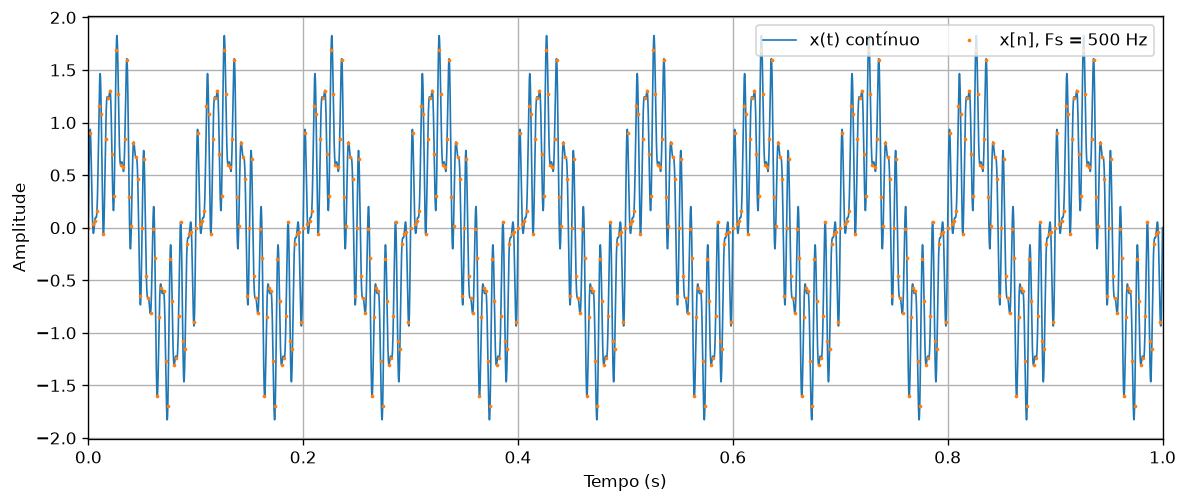

Número de amostras: 500


In [7]:
def sinal(t):
    t = np.asarray(t, dtype=float)
    return np.sin(20*np.pi*t) + 0.6*np.sin(240*np.pi*t) + 0.3*np.sin(400*np.pi*t)
t_cont = np.linspace(0, DURACAO, 10001)
t = np.arange(0, DURACAO, 1/FS); x = sinal(t)
fig, ax = plt.subplots(figsize=(10,4.3)); ax.plot(t_cont, sinal(t_cont), lw=1, label='x(t) contínuo')
ax.plot(t, x, '.', ms=2.4, label='x[n], Fs = 500 Hz'); ax.set(xlabel='Tempo (s)', ylabel='Amplitude', xlim=(0,1)); ax.legend(ncol=2)
fig.tight_layout(); fig.savefig(OUT/'sinal_continuo_amostrado.png'); plt.show()
print('Número de amostras:', len(x))

## 2. Butterworth analógico de terceira ordem
$H_a(s)=\Omega_c^3/(s^3+2\Omega_c s^2+2\Omega_c^2s+\Omega_c^3)$, com $\Omega_c=2\pi(50)$ rad/s.

Numerador: [31006276.68029982]
Denominador: [1.00000000e+00 6.28318531e+02 1.97392088e+05 3.10062767e+07]


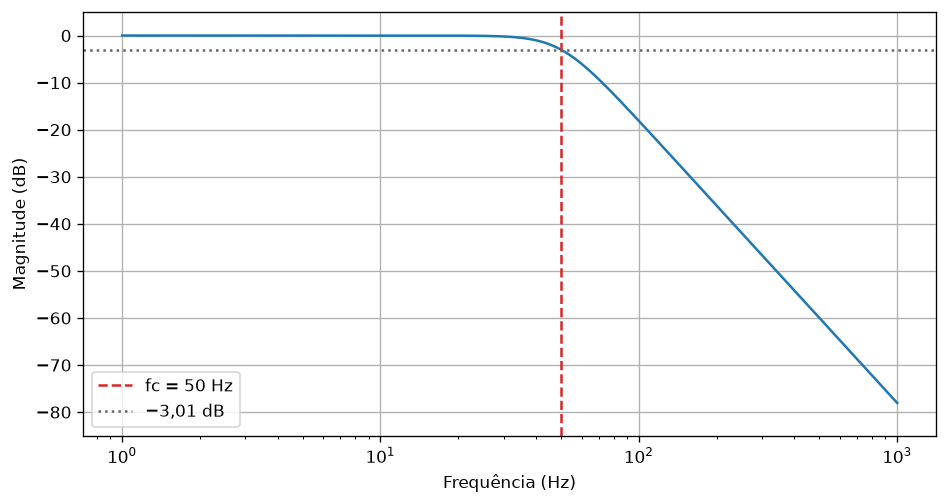

In [8]:
def butterworth_analogico(fc=FC):
    wc = 2*np.pi*fc
    return np.array([wc**3]), np.array([1., 2*wc, 2*wc**2, wc**3])
num_a, den_a = butterworth_analogico(); wc = 2*np.pi*FC
print('Numerador:', num_a); print('Denominador:', den_a)
f_a = np.unique(np.r_[np.logspace(0,3,3000), FC]); s = 1j*2*np.pi*f_a
Ha = wc**3/(s**3 + 2*wc*s**2 + 2*wc**2*s + wc**3)
fig, ax = plt.subplots(figsize=(8,4.3)); ax.semilogx(f_a, 20*np.log10(abs(Ha)))
ax.axvline(FC, color='C3', ls='--', label='fc = 50 Hz'); ax.axhline(-3.0103, color='.4', ls=':', label='−3,01 dB')
ax.set(xlabel='Frequência (Hz)', ylabel='Magnitude (dB)', ylim=(-85,5)); ax.legend(); fig.tight_layout()
fig.savefig(OUT/'bode_analogico.png'); plt.show()

## 3. IIR por transformação bilinear
Usa-se $s=2F_s(1-z^{-1})/(1+z^{-1})$ e pré-distorção $\Omega_p=2F_s\tan(\pi f_c/F_s)$ para preservar exatamente o corte de 50 Hz.

In [9]:
def butterworth_bilinear(fs=FS, fc=FC):
    wp = float(2*fs*np.tan(np.pi*fc/fs)); k = float(2*fs)
    p, m = np.poly1d([1.,1.]), np.poly1d([-1.,1.])  # 1+q e 1-q, q=z^-1
    den = (m**3)*k**3 + (m**2*p)*(2*wp*k**2) + (m*p**2)*(2*wp**2*k) + (p**3)*wp**3
    num = (p**3)*wp**3
    a, b = np.asarray(den.c)[::-1], np.asarray(num.c)[::-1]
    return b/a[0], a/a[0], wp
def resposta_frequencia(b, a=(1.,), fs=FS, pontos=8192):
    b, a = np.asarray(b), np.asarray(a); f = np.linspace(0,fs/2,pontos); w = 2*np.pi*f/fs
    Eb = np.exp(-1j*np.outer(w,np.arange(len(b)))); Ea = np.exp(-1j*np.outer(w,np.arange(len(a))))
    return f, (Eb@b)/(Ea@a)
def filtrar(b, a, x):
    b, a, x = np.asarray(b), np.asarray(a), np.asarray(x); y = np.zeros(len(x))
    for n in range(len(x)):
        for k in range(min(len(b),n+1)): y[n] += b[k]*x[n-k]
        for k in range(1,min(len(a),n+1)): y[n] -= a[k]*y[n-k]
        y[n] /= a[0]
    return y
b_iir, a_iir, omega_pre = butterworth_bilinear()
print('Omega pré-distorcida:', omega_pre); print('b =',b_iir); print('a =',a_iir)
print('Polos:',np.roots(a_iir)); print('Maior módulo:',max(abs(np.roots(a_iir))))

Omega pré-distorcida: 324.9196962329063
b = [0.01809893 0.0542968  0.0542968  0.01809893]
a = [ 1.         -1.76004188  1.18289326 -0.27805992]
Polos: [0.62525822+0.39341515j 0.62525822-0.39341515j 0.50952545+0.j        ]
Maior módulo: 0.7387308816541083


## 4. FIR de ordem 40 por janela de Hamming
$h_d[n]=(2f_c/F_s)\,\mathrm{sinc}[(2f_c/F_s)(n-20)]$ é multiplicada por $w[n]=0{,}54-0{,}46\cos(2\pi n/40)$ e normalizada para ganho unitário em CC.

41 coeficientes FIR:
[-6.25225142e-19 -8.45601618e-04 -1.72831385e-03 -2.32307799e-03
 -1.96757499e-03  1.67818932e-18  3.61198879e-03  7.73058176e-03
  1.00612612e-02  7.98021708e-03 -4.22026971e-18 -1.27527753e-02
 -2.58761960e-02 -3.24638770e-02 -2.53315871e-02  6.76235010e-18
  4.27690414e-02  9.60841254e-02  1.48317526e-01  1.86490935e-01
  2.00486654e-01  1.86490935e-01  1.48317526e-01  9.60841254e-02
  4.27690414e-02  6.76235010e-18 -2.53315871e-02 -3.24638770e-02
 -2.58761960e-02 -1.27527753e-02 -4.22026971e-18  7.98021708e-03
  1.00612612e-02  7.73058176e-03  3.61198879e-03  1.67818932e-18
 -1.96757499e-03 -2.32307799e-03 -1.72831385e-03 -8.45601618e-04
 -6.25225142e-19]


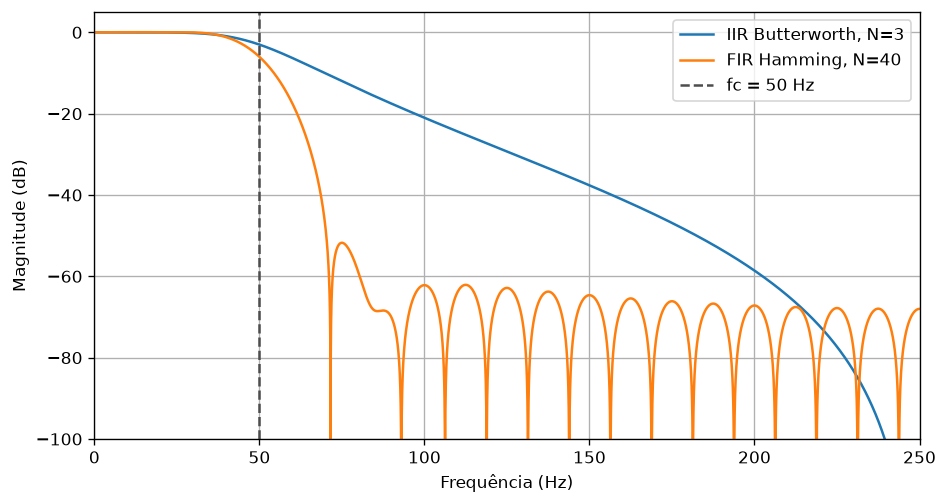

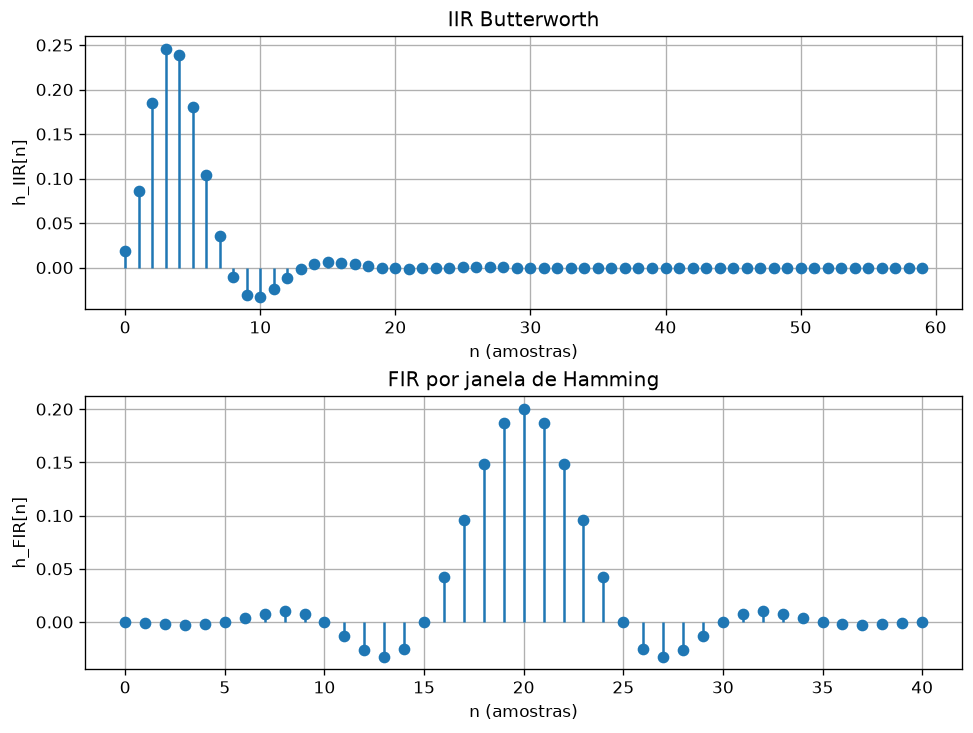

In [10]:
def fir_hamming(fs=FS, fc=FC, ordem=40):
    n=np.arange(ordem+1); hd=2*fc/fs*np.sinc(2*fc/fs*(n-ordem/2))
    janela=0.54-0.46*np.cos(2*np.pi*n/ordem); h=hd*janela
    return h/np.sum(h)
h_fir=fir_hamming(); print('41 coeficientes FIR:'); print(h_fir)
f,H_iir=resposta_frequencia(b_iir,a_iir); _,H_fir=resposta_frequencia(h_fir)
fig,ax=plt.subplots(figsize=(8,4.3)); ax.plot(f,20*np.log10(np.maximum(abs(H_iir),1e-8)),label='IIR Butterworth, N=3')
ax.plot(f,20*np.log10(np.maximum(abs(H_fir),1e-8)),label='FIR Hamming, N=40'); ax.axvline(FC,color='.3',ls='--',label='fc = 50 Hz')
ax.set(xlabel='Frequência (Hz)',ylabel='Magnitude (dB)',xlim=(0,250),ylim=(-100,5)); ax.legend(); fig.tight_layout()
fig.savefig(OUT/'respostas_frequencia.png'); plt.show()
impulso=np.r_[1.,np.zeros(119)]; h_iir=filtrar(b_iir,a_iir,impulso)
fig,(ax1,ax2)=plt.subplots(2,1,figsize=(8,6),constrained_layout=True)
ax1.stem(np.arange(60),h_iir[:60],basefmt=' '); ax1.set(title='IIR Butterworth',xlabel='n (amostras)',ylabel='h_IIR[n]')
ax2.stem(np.arange(len(h_fir)),h_fir,basefmt=' '); ax2.set(title='FIR por janela de Hamming',xlabel='n (amostras)',ylabel='h_FIR[n]')
fig.savefig(OUT/'respostas_impulso.png'); plt.show()

## 5 e 6. Filtragem e comparação
A filtragem usa diretamente a equação de diferenças. O FIR possui fase linear e atraso de 20 amostras (40 ms); o IIR possui menor custo e latência, mas fase não linear.

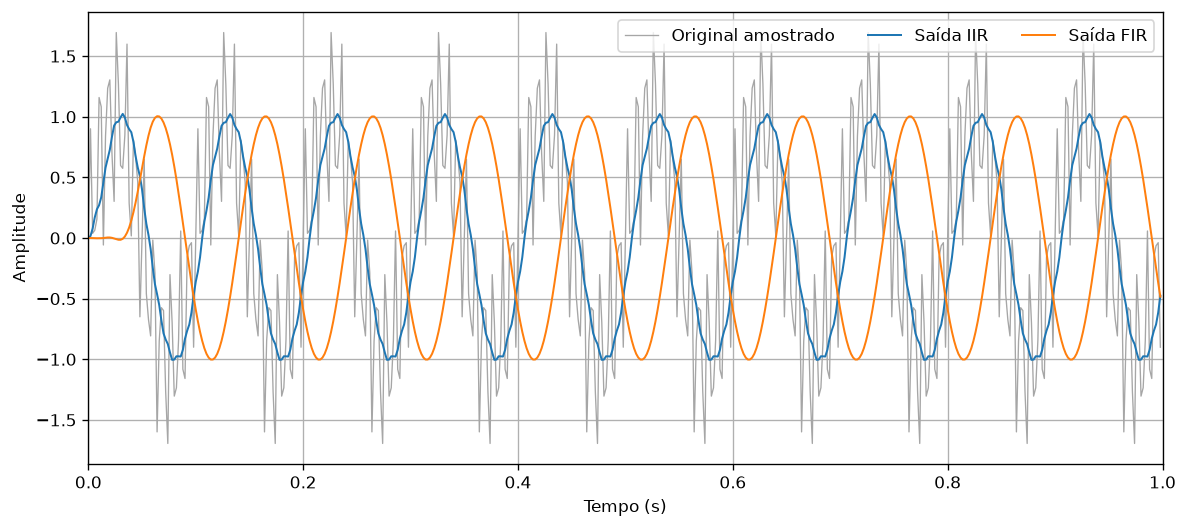

IIR em 50 Hz (dB): -3.0085998830437655
Simetria FIR (erro máximo): 1.3877787807814457e-17
Ganho FIR em CC: 1.0


In [11]:
y_iir=filtrar(b_iir,a_iir,x); y_fir=filtrar(h_fir,[1.],x)
fig,ax=plt.subplots(figsize=(10,4.5)); ax.plot(t,x,color='.65',lw=.8,label='Original amostrado')
ax.plot(t,y_iir,lw=1.2,label='Saída IIR'); ax.plot(t,y_fir,lw=1.2,label='Saída FIR')
ax.set(xlabel='Tempo (s)',ylabel='Amplitude',xlim=(0,1)); ax.legend(ncol=3); fig.tight_layout()
fig.savefig(OUT/'comparacao_saidas.png'); plt.show()
i=np.argmin(abs(f-FC)); print('IIR em 50 Hz (dB):',20*np.log10(abs(H_iir[i])))
print('Simetria FIR (erro máximo):',max(abs(h_fir-h_fir[::-1]))); print('Ganho FIR em CC:',sum(h_fir))